# **Detección de spam usando la Máquina de Soporte Vectorial**
En el ámbito de los correos electrónicos nos interesamos por clasificar los mensajes recibidos en las categorías spam y no spam. Suponiendo que los datos (correos electrónicos ya clasificados) son linealmente separables queremos usar la Máquina Soporte Vectorial (MSV) con el objetivo de determinar para un email NO observado previamente a que categoría pertenece.

### **Preprocesamiento de los datos**


Tomemos un número $N$ de emails que podamos clasificar en las dos categorías de nuestro interés.

Cuando tengamos estos $N$ emails etiquetados debemos determinar una manera de representarlos en parejas $(\mathbf{x},y)$ que podamos usar en nuestro modelo. Para esto tomaremos las palabras que contiene el i-ésimo email y las guardaremos en un vector $p_i$, posteriormente usando un diccionario con $20\ 000$ palabras ordenadas de la A a la Z crearemos un nuevo vector de unos y ceros con dimensión $D=20\ 000$ por cada email, donde la j-ésima componente del i-ésimo vector es $1$ si la j-ésima palabra del diccionario está en el vector $p_i$ y es $0$ en caso contrario. Es decir, ahora tenemos $N$ vectores en $\mathbb{R}^D$ (uno por cada correo), cada uno de estos actuará como el valor de $\mathbf{x}$, mientras que su respectivo $y$ será $+1$ si dicho correo es spam y $-1$ si no es spam, de este modo hemos armado nuestro conjunto de datos $\big\{(\mathbf{x_i},y_i)\big\}_{i=1}^N$.

Como los datos son linealmente separables, nos interesamos en hallar un hiperplano que sirva como frontera de decisión entre los correos spam y no spam, intuitivamente queremos obtener dos semiespacios $H_+$ y $H_-$ tales que el primero contenga todos los correos spam y el otro los no spam.

### **Generación de Datos Gaussianos**

Con el fin de realizar una deducción más explícita, haremos un ejemplo, para ello vamos a generar dos conjuntos de datos que sigan una distribución gaussiana (normal) en 2D, simulando las dos clases distintas (spam y no spam). Nuestro objetivo será mostrar cómo un clasificador lineal podría separar estos datos.

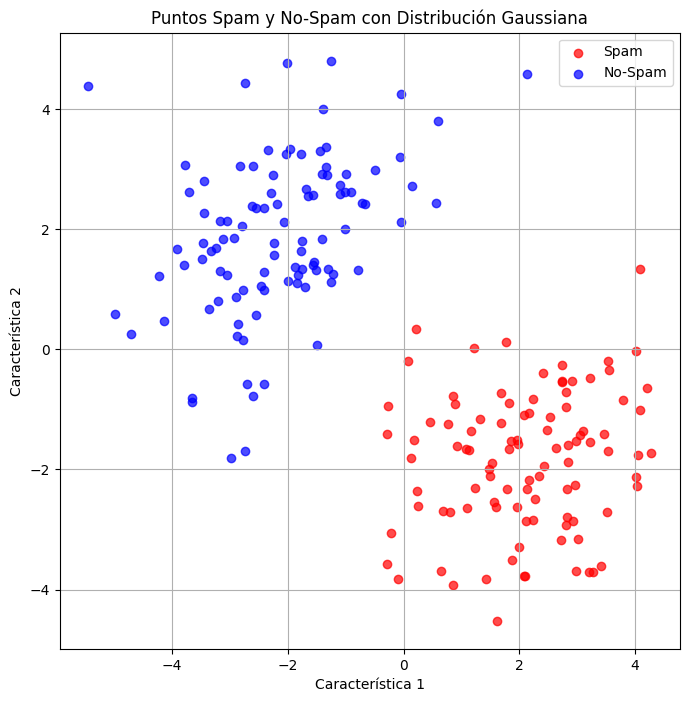

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)                                  # Semilla

mean1 = [2, -2]                                     # Centro de la distribución
cov1 = [[1.65, 0.5], [0.5, 1.65]]                   # Matriz de covarianza
num_samples = 100
X1 = np.random.multivariate_normal(mean1, cov1, num_samples)

mean2 = [-2, 2]
cov2 = [[1.65, 0.5], [0.5, 1.65]]
X2 = np.random.multivariate_normal(mean2, cov2, num_samples)

plt.figure(figsize=(8, 8))
plt.scatter(X1[:, 0], X1[:, 1], color='red', label='Spam', alpha=0.7)
plt.scatter(X2[:, 0], X2[:, 1], color='blue', label='No-Spam', alpha=0.7)
plt.title('Puntos Spam y No-Spam con Distribución Gaussiana')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.grid(True)
plt.show()

La ecuación del hiperplano separador es $f(\mathbf{x})=\mathbf{wx}-b$, donde $\mathbf{w}$ es un vector de pesos perpendicular al hiperplano, $\mathbf{x}$ es un vector de entrada y $b$ es un escalar de sesgo que determina la distancia del hiperplano al origen. En particular un punto $\bar{\mathbf{x}}$ está en el hiperplano si $\mathbf{w\bar{x}}-b=0$.

Nótese que $\mathbf{w'}$ y $\mathbf{b'}$ particulares definen hiperplanos diferentes, es decir, reglas de clasificación diferentes.

Nuestra primer regla de clasificación será $y_i=sign(\mathbf{wx_i}-b)$ cuyas restricciones son:
$$\begin{cases}
      \mathbf{wx_i}-b\geq +1\ \ si\ \ y_i=+1\\
      \mathbf{wx_i}-b\geq -1\ \ si\ \ y_i=-1\\
   \end{cases}$$

Ahora nos enfocaremos en encontrar los $\mathbf{w^*}$ y $b^*$ óptimos que generen el hiperplano que separe las dos clases con el máximo margen (distancia entre los ejemplos más cercanos de las dos clases).


En la MSV definimos dos hiperplanos paralelos que tocan los puntos más cercanos de cada clase: $H_+:\mathbf{wx_+}-b=1$ y  $H_-:\mathbf{wx_-}-b=-1$, aquí $\mathbf{w}$ es perpendicular a ambos planos.

Obsérvese que al restar la segunda ecuación de la primera, resulta $\mathbf{w\cdot (x_+-x_-)}=2$.

Para hallar la distancia $L$ entre los dos planos $H_+$ y $H_-$, tomemos $\mathbf{x_+}$ en el plano positivo y $\mathbf{x_-}$ en el plano negativo, así el vector que los une es $\mathbf{v=x_+-x_-}$. La distancia perpendicular entre los planos es la proyección del vector $\mathbf{v}$ sobre el vector unitario $\mathbf{\hat{w}=\frac{w}{\|w\|}}$ que se define como $L=\|\mathbf{v}\|cos\theta$, donde $\theta$ representa el ángulo entre los vectores $\mathbf{v}$ y $\mathbf{w}$, luego como $\mathbf{\frac{w}{\|w\|}\cdot v}=\|\hat{w}\|\ \|v\|cos\theta$, resulta $L=\mathbf{\frac{w\cdot v}{\|w\|}}=\frac{2}{\|\mathbf{w}\|}$


### **Optimización**
Queremos maximizar el margen, o análogamente minimizar $\|w\|$, con esto en mente, planteamos lo siguiente:
$$\begin{cases}
      min_{\mathbf{w},b}\|\mathbf{w}\| \\
      s.a\ \ y_i(\mathbf{wx_i}-b)\geq 1\ \ \ \forall i=1,...,N
   \end{cases}$$
Esto es convenientemente equivalente a:
$$\begin{cases}
      min_{\mathbf{w},b}\frac{1}{2}\|\mathbf{w}\|^2 \\
      s.a\ \ y_i(\mathbf{wx_i}-b)\geq 1\ \ \ \forall i=1,...,N
   \end{cases}$$
Puesto que tienen el mismo óptimo y simplifica derivadas, permitiendo una mejor formulación dual.

Ahora, introduciendo Multiplicadores de Lagrange $\alpha_i\geq 0$ definimos
$$L(\mathbf{w},b,\alpha)=\frac{1}{2}\|\mathbf{w}\|^2-\sum_{i=1}^N\alpha_i(y_i(\mathbf{wx_i}-b)-1)$$
Procedemos derivando parcialmente:

Respecto a $\mathbf{w}$:
\begin{equation*}
\begin{split}
\frac{\partial L}{\partial \mathbf{w}} & = \frac{\partial}{\partial \mathbf{w}}\Bigg(\frac{1}{2}\|\mathbf{w}\|^2\Bigg)-\frac{\partial}{\partial \mathbf{w}}\Bigg(\sum_{i=1}^N\alpha_i(y_i(\mathbf{wx_i}-b)-1)\Bigg) \\
 & = \frac{\partial}{\partial \mathbf{w}}\Bigg(\frac{1}{2}\sqrt{\mathbf{w}\cdot \mathbf{w}}\ ^2\Bigg)-\sum_{i=1}^N\Bigg(\frac{\partial}{\partial \mathbf{w}}\alpha_i(y_i(\mathbf{wx_i}-b)-1)\Bigg) \\
 & = \frac{\partial}{\partial \mathbf{w}}\Bigg(\frac{1}{2}\mathbf{w}^2\Bigg)-\sum_{i=1}^N\alpha_i\Bigg(\frac{\partial}{\partial \mathbf{w}}(y_i(\mathbf{wx_i}-b)-1)\Bigg) \\
 & = \mathbf{w}-\sum_{i=1}^N\alpha_iy_i\mathbf{x_i} \\
 \end{split}
\end{equation*}
Igualando a cero:
\begin{equation}
   \mathbf{w}=\sum_{i=1}^N\alpha_iy_i\mathbf{x_i}\tag{1}
\end{equation}

Nótese que esto indica que el vector $\mathbf{w}$ es combinación lineal de los datos de entrenamiento.

Respecto a $b$:
\begin{equation*}
\begin{split}
\frac{\partial L}{\partial b} & = \frac{\partial}{\partial b}\Bigg(\frac{1}{2}\|\mathbf{w}\|^2\Bigg)-\frac{\partial}{\partial b}\Bigg(\sum_{i=1}^N\alpha_i(y_i(\mathbf{wx_i}-b)-1)\Bigg) \\
 & = -\sum_{i=1}^N\alpha_i\Bigg(\frac{\partial}{\partial b}(y_i(\mathbf{wx_i}-b)-1)\Bigg) \\
 & = -\sum_{i=1}^N\alpha_iy_i \\
 \end{split}
\end{equation*}
Igualando a cero:
\begin{equation*}
    \sum_{i=1}^N\alpha_iy_i=0\tag{2}
\end{equation*}

Respecto a $\alpha$:
\begin{equation}
\frac{\partial L}{\partial \alpha} = y_i(\mathbf{wx_i}-b)-1
\end{equation}
Igualando a cero:
\begin{equation}
y_i(\mathbf{wx_i}-b)=1\tag{3}
\end{equation}
Usando la ecuación $(3)$ es posible despejar $b$, para esto multipliquemos $y_i$ a ambos lados de la ecuación, como $y_i^2=1$ resulta $\mathbf{wx_i}-b=y_i$, luego
\begin{equation}
b=\mathbf{wx_i}-y_i\tag{4}
\end{equation}
Expandiendo el Lagrangiano, obtenemos la siguiente expresión:
$$L(\mathbf{w},b,\alpha)=\frac{1}{2}(\mathbf{w}\cdot\mathbf{w})-\sum_{i=1}^N\alpha_iy_i\mathbf{wx_i}+\sum_{i=1}^N\alpha_iy_ib+\sum_{i=1}^N\alpha_i$$
Al reemplazar aquí las ecuaciones $(1)$ y $(2)$, resulta:
\begin{equation*}
\begin{split}
L(\mathbf{w},b,\alpha) & = \frac{1}{2}\Bigg(\sum_{i=1}^N\alpha_iy_i\mathbf{x_i}\cdot\sum_{k=1}^N\alpha_ky_k\mathbf{x_k}\Bigg)-\sum_{i=1}^N\alpha_iy_i\Bigg(\sum_{k=1}^N\alpha_ky_k\mathbf{x_k}\Bigg)\mathbf{x_i}+b\sum_{i=1}^N\alpha_iy_i+\sum_{i=1}^N\alpha_i \\
 & = \frac{1}{2}\Bigg(\sum_{i=1}^N\alpha_iy_i\mathbf{x_i}\cdot\sum_{k=1}^N\alpha_ky_k\mathbf{x_k}\Bigg)-\sum_{i=1}^N\alpha_iy_i\Bigg(\sum_{k=1}^N\alpha_ky_k\mathbf{x_k}\Bigg)\mathbf{x_i}+\sum_{i=1}^N\alpha_i \\
 & = \frac{1}{2}\Bigg(\sum_{i=1}^N\sum_{k=1}^N\alpha_i\alpha_ky_iy_k(\mathbf{x_i}\cdot\mathbf{x_k})\Bigg)-\Bigg(\sum_{i=1}^N\sum_{k=1}^N\alpha_i\alpha_ky_iy_k(\mathbf{x_i}\cdot\mathbf{x_k})\Bigg)+\sum_{i=1}^N\alpha_i \\
 & = -\frac{1}{2}\Bigg(\sum_{i=1}^N\sum_{k=1}^N\alpha_i\alpha_ky_iy_k(\mathbf{x_i}\cdot\mathbf{x_k})\Bigg)+\sum_{i=1}^N\alpha_i \\
 \end{split}
\end{equation*}
Por tanto, el siguiente paso es usar un optimizador para determinar el $\alpha^*$ óptimo que maximice $L(\mathbf{w},b,\alpha)$.
$$\begin{cases}
      max_{\alpha}\sum_{i=1}^N\alpha_i-\frac{1}{2}\sum_{j=1}^N\sum_{k=1}^N\alpha_j\alpha_ky_jy_k(x_j\cdot x_k) \\
      s.a\ \ \alpha_i\geq 0\ \ \ \forall i=1,...,N \\
      \ \ \ \ \ \ \ \sum_{i=1}^N\alpha_iy_i=0\ \ \ \forall i=1,...,N \\
   \end{cases}$$
En la solución $\alpha^*$, algunos $\alpha_i=0$ y otros son positivos ($\alpha_i>0$), estos últimos son los vectores de soporte que determinan el hiperplano, luego usando $(1)$ podemos ahora hallar $\mathbf{w}^*$ y posteriormente usando $(4)$ hallar $b^*$.

La regla de clasificación original era $y_i=sign(wx_i-b)$, luego del procedimiento anterior obtenemos una nueva función de decisión $y_i=sign(\mathbf{w}^*x-b^*)$ donde solo los vectores soporte participan.

### **Aplicación**
A continuación aplicaremos el algoritmo explicado usando Python con la librería Scikit-Learn (sklearn), puesto que allí el optimizador ya viene integrado y resuelve las ecuaciones de Lagrange internamente y nos muestra los valores óptimos de $\mathbf{w}^*$, $b^*$ y los vectores de soporte.

Posteriormente se muestra un gráfico que presenta los resultados obtenidos.

In [ ]:
from sklearn import svm

X=np.concatenate((X1,X2),axis=0)                                  # Coordenadas de los datos
y = np.concatenate((np.full(len(X1), 1), np.full(len(X2), -1)))   # Vector de etiquetas

clf = svm.SVC(kernel='linear', C=1.0)                             # Crear el modelo con kernel lineal (para hallar el hiperplano wx-b)
clf.fit(X, y)

w = clf.coef_[0]                                                  # Obtener los resultados de las ecuaciones (2) y (5)
b = clf.intercept_[0]
alphas = np.abs(clf.dual_coef_[0])                                # Multiplicadores de Lagrange (solo para vectores de soporte)

print(f"Vector w^*: {w}")
print(f"Sesgo b^*: {b}")
print(f"Vectores de soporte: {clf.support_vectors_}")

Vector w^*: [ 1.24709615 -0.99729278]
Sesgo b^*: 0.7187863006778442
Vectores de soporte: [[-2.73133221 -1.69181994]
 [ 0.56866805  2.43414355]
 [ 0.06970618 -0.1946022 ]
 [ 0.21173165  0.33707244]]


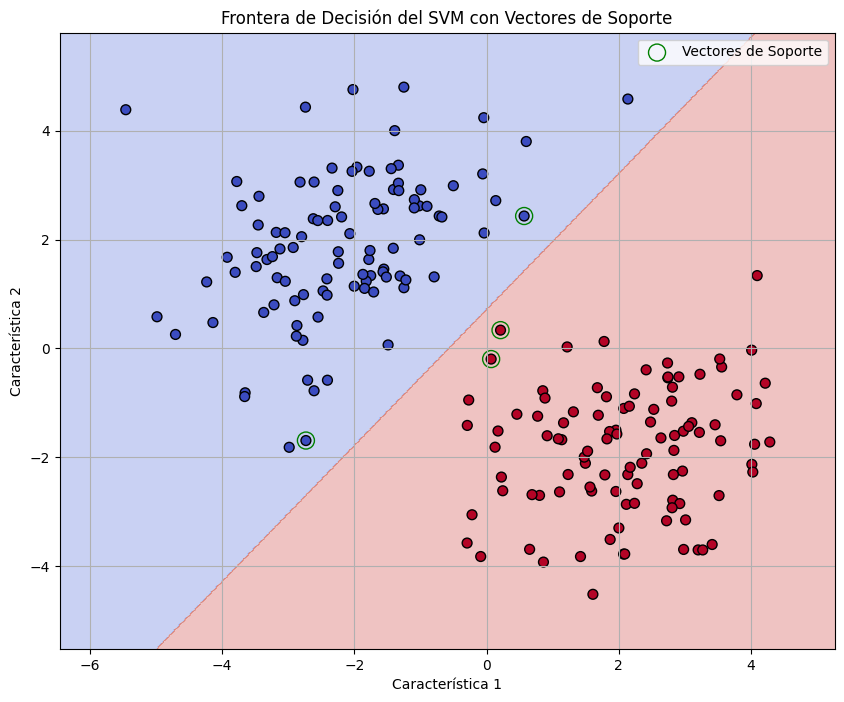

In [ ]:
plt.figure(figsize=(10, 8))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)                                            # Dibujar la frontera de decisión y los márgenes
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k')

plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],                                 # Resaltar los vectores de soporte
            s=150, facecolors='none', edgecolors='green', label='Vectores de Soporte')

plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Frontera de Decisión del SVM con Vectores de Soporte')
plt.legend()
plt.grid(True)
plt.show()

En el contexto del spam, cada $\mathbf{x_i}$ es un correo representado como vector de palabras, el hiperplano separa el espacio en región spam y región no-spam y los vectores soporte actúan como "correos frontera" que pueden ser promociones ambiguas o emails de periódicos legítimos con lenguaje publicitario; estos ejemplos determinan el clasificador.

Para nuevo correo $\mathbf{x}$, el modelo actúa de la siguiente manera:
1) Lo compara con correos críticos (vectores soporte).
2) Evalúa similitudes.
3) Pondera por el peso de influencia y su clase.
4) Decide por el signo.
En otros términos, la decisión es una suma ponderada de similitudes en la que solo intervienen los vectores soporte.